# Krittika Summer Projects 7.0: Computational Astronomy Assignment: Gravitational Lensing

This assignment explores the phenomenon of **gravitational lensing** through a sequence of computational and conceptual exercises. You will gradually build a working model simulation, beginning with classical optics and extending to relativistic light deflection by massive objects.

## Structure of the Assignment

The assignment is divided into multiple parts, each building on the previous one:

- (a) Classical thin lens optics  
- (b) Gravitational lensing: theory and derivation  
- (c) Simulation of lensing for a single point source  
- (d) Extension to extended sources  
- (e) Formation of Einstein rings  
- (f) Inverse problem: reconstruction of the source (graphically)
- (g) BONUS: Reconstruction of the source (bitmap image)

Each section introduces new ideas while reinforcing earlier ones. You are encouraged to move sequentially, but partial completion is fully acceptable.

## Expectations and Evaluation

This assignment is designed to prioritise **understanding over completion**.

- Partial attempts will be **valued and credited**
- Clear reasoning and explanation of your approach are important
- It is acceptable if some parts of the code do not fully work, as long as your thought process is evident

You should aim to:
- Show intermediate steps
- Explain assumptions or approximations
- Identify where difficulties arise

Submissions will be evaluated not only on correctness, but also on **clarity of reasoning and effort**.

## Role of Visualisation

A central component of this assignment is the use of **visualisation to understand physical systems**. You will use the Python library Matplotlib for all plotting tasks.

Visualisation is an essential tool in computational physics and is widely used in research contexts, including Krittika Summer Projects (KSPs). Producing clear, accurate, and interpretable plots is a fundamental skill.


## Matplotlib Guidelines

All plots in this assignment must be created using Matplotlib (refer https://matplotlib.org/stable/users/index.html for more information). For clarity and consistency, use small marker sizes while plotting points so that structure is not obscured:

```python
plt.scatter(x, y, s=3.5)
```
---


## Part (a): Classical Thin Lens Optics

Before moving to gravitational lensing, we begin with a familiar system from geometrical optics: the **thin convex lens**. This serves as an important conceptual and mathematical analogue for understanding how light rays are deflected and how images are formed.

In this part, you will analyse how a point source is imaged by a thin lens using both analytical expressions and graphical construction.

### Physical Setup

- Consider a **thin convex lens** placed along the vertical line \( x = 0 \), extending from \( y = -1.5 \) to \( y = +1.5 \).
- The lens has a **focal length** \( f = 1 \) (in arbitrary units).
- A point source is located at coordinates \( (x_0, y_0) \).


#### (i) Analytical Image Formation

- Given a point \( (x_0, y_0) \) (take user input as a floating point), compute the image position \( (x', y') \)
- Carefully consider and handle all possible cases.


#### (ii) Ray Diagram Construction

You will then construct a **graphical ray diagram** using Matplotlib:

- Draw a **horizontal incident ray** from the point source to the lens
- Show how this ray is refracted by the lens


## Explaination
The lens formulais given by $$\frac{1}{v} - \frac{1}{u} = \frac{1}{f}$$ Using this formula we find the postion of image and plot it. Since the ray diagram construction only asked us to draw a horizontal incident ray and show it's refraction it did it. the refracted ray is the line joining the point where the horizontal ray hits the lens and the final image.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
m = float('inf')
def position (pos, f):
    x, y = pos
    if (x> 0):
        f *= -1
    if (x == 0):
        return [x, y]
    if abs(abs(x) - abs(f)) <= 1e-10:
        return [m, m]
    x1 = (x*f)/(x+f)
    y1 = x1/x * y
    return [x1, y1]
f = 1
x, y = map(float, input().split())
x0 = [x, y]
x1, y1 = position(x0, f)
if (x1 == float('inf')):
    print('image at infinity')
else:
    print(x1, y1)






-5 0.7
1.25 -0.175


Thus we get the x and y coordinates of the image and

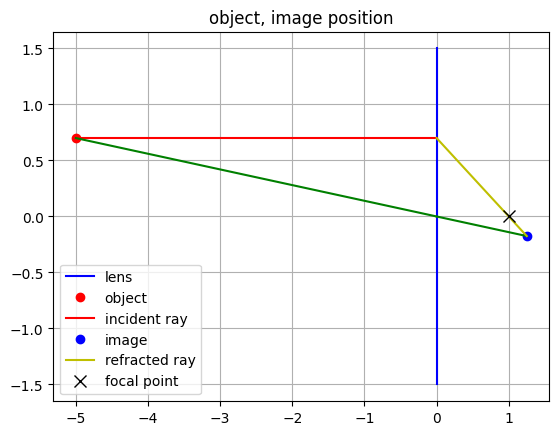

In [13]:
#ploting the graph
plt.plot([0, 0], [-1.5, 1.5], 'b-', label = 'lens')
plt.plot(x, y, 'ro', label = 'object')
plt.plot([0, x],[y, y] , 'r-', label = 'incident ray')
plt.plot([0, x],[0, y], color = 'green')


if (abs(x1) != float('inf')):
    plt.plot(x1, y1, 'bo', label = 'image')
    plt.plot([x1, 0],[y1,0], color = 'green')
if (abs(x1) == float('inf')):
    plt.title('image at infinity')
    x1 = f
    if (x > 0):
        x1 = -f
    plt.plot([x1, 0], [0, y], 'y-', label = 'refracted ray')

else:
    plt.title('object, image position')
    plt.plot([0, x1], [y, y1], 'y-', label = 'refracted ray')
plt.grid()
plt.plot(f, 0, 'kx', markersize=8, label='focal point')
plt.legend()
plt.show()

In the above part i only focused on showing one incident ray parallel to principle axes and how it gets refracted .

## Part (b): Gravitational Lensing — Theory

In this part, you will study how a massive object bends light and produces multiple images of a source.

![Gravitational Lensing Diagram](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/0b3c4e750f8e8473750b947bc84eb1a49259c091/Computational_Astronomy/Grav_Lensing_Diagram.png)

### Key Relations

Deflection angle:
$$
\tilde{\alpha} = \frac{4GM}{c^2 \xi}, \quad \xi = d_L \tan\theta
$$

Lens equation:
$$
\theta = \beta + \frac{d_{LS}}{d_S}\tilde{\alpha}
$$

Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2}\frac{d_{LS}}{d_L d_S}}
$$


### Task

- Solve the **exact equation** numerically  
- Find an approximate equation for situations $\theta_E$ is small. Solve the **approximate equation** analytically.
- Compute and plot the **percentage error** vs $\,\beta / \theta_E\,$  Identify the breakaway point where the error starts growing out of bounds.

Final equation-
$$\theta = \beta + \theta_E^2 / \tan{\theta}$$
if $\theta$ is small, we can say $\theta =  \beta + \theta_E^2 / \theta$
hence $\theta = \frac{\beta \pm \sqrt{\beta^2 + 4 \theta_E^2}}{2}$. In this portion as per the parts i will consider both type of solutions the exact and approcimate but in later parts i will use the approximate solutions to find the results

0.00010859355413651401


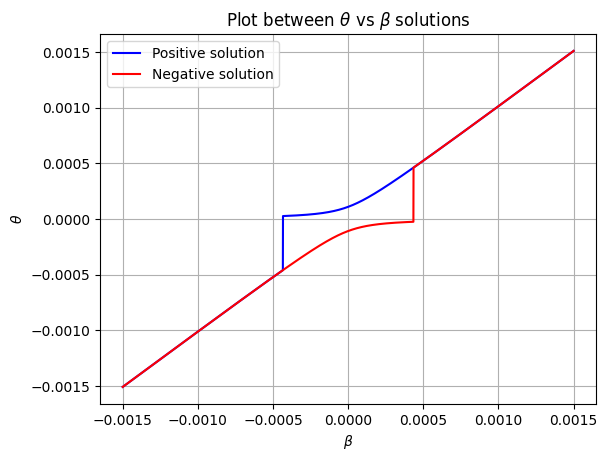

In [14]:
#finding solutions- task 1
from scipy.optimize import fsolve
dl = 5e11
ds = 9.75e17
dls = 9.75e17
G = 6.67e-11
M = 1.989e30 # solar mass
c = 3e8

theta_E = np.sqrt( 4 * G * M /c**2 * dls/(dl*ds))
B = np.linspace (-0.0015, 0.0015, 10001)
print(theta_E)
def f(x, b):
    return x- b - theta_E**2/np.tan(x)
r_plus = []
r_minus = []
for b in B:
    r = fsolve(f, - theta_E, args = (b,))[0]
    r_minus.append(r)
    r1 = fsolve(f, theta_E, args = (b,))[0]
    r_plus.append(r1)
plt.plot(B, r_plus, 'b-', label = 'Positive solution')
plt.plot(B, r_minus, 'r-', label = 'Negative solution')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.title(r"Plot between $\theta$ vs $\beta$ solutions")
plt.grid()
plt.show()


## observations -
The solutions $\theta_+$ and $\theta_-$ almost coincide before some value of $\beta$ but again it divergen in the values between them

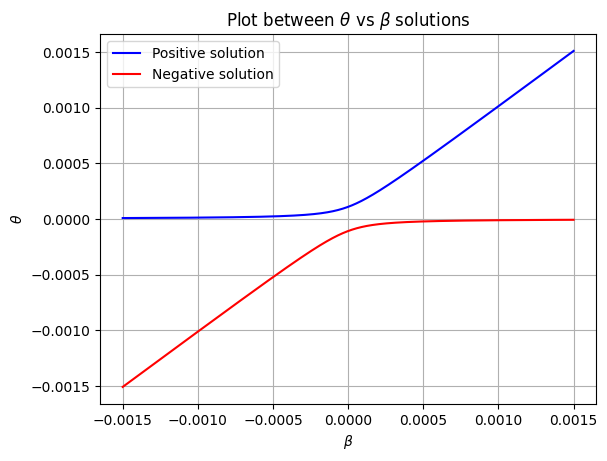

In [15]:
# part 2- approximate solution for small theta E
def f_minus(b, theta_e):
    return (b - np.sqrt(b**2 + 4* theta_e**2))/2
def f_plus(b, theta_e):
    return (b + np.sqrt(b**2 + 4* theta_e**2))/2
t_plus = f_plus(B, theta_E)
t_minus = f_minus(B, theta_E)
plt.plot(B, t_plus, 'b-', label = 'Positive solution')
plt.plot(B, t_minus, 'r-', label = 'Negative solution')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.title(r"Plot between $\theta$ vs $\beta$ solutions")
plt.grid()
plt.show()



if we assume the tan approximation then one of the solution diverges beyond certain value and other beyond the other value.

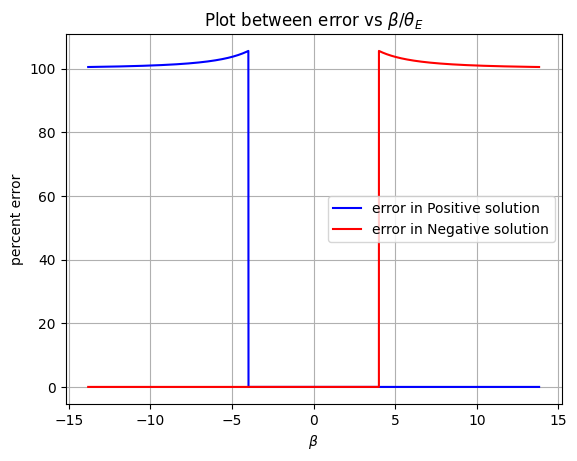

error burst in positive solution at -3.9974748358847214
error burst in negative solution at 4.000237430795491


In [16]:
#part 3- error graph
err_plus = np.abs((t_plus - r_plus)/r_plus) * 100
err_minus = np.abs((t_minus - r_minus)/r_minus)* 100
plt.plot(B/theta_E, err_plus, 'b-', label = 'error in Positive solution')
plt.plot(B/theta_E, err_minus, 'r-', label = 'error in Negative solution')
plt.xlabel(r'$\beta$')
plt.ylabel(r'percent error')
plt.legend()
plt.title(r"Plot between error vs $\beta / \theta_E$")
plt.grid()
plt.show()

# finding the index at which diff is maximum
max_plus =0
max_minus = 0

max_ind_plus = 0
max_ind_minus = 0
for i in range (1, len(B)):
    if (np.abs(err_plus[i]- err_plus[i-1]) > max_plus):
        max_plus = np.abs(err_plus[i]- err_plus[i-1])
        max_ind_plus = i
    if (abs(err_minus[i]- err_minus[i-1]) > max_minus):
        max_minus = np.abs(err_minus[i]- err_minus[i-1])
        max_ind_minus = i
print("error burst in positive solution at", B[max_ind_plus]/theta_E)
print("error burst in negative solution at", B[max_ind_minus]/theta_E)


The error is bursts at $|\beta / \theta_E|$ = 4. We can see it graphically also by adjusting the plt.xlim

## Part (c): Simulation of a Single Lensed Point Source

In this part, you will simulate gravitational lensing of a **single point source** by a massive object placed at the origin.

Assume the following constants (fixed for the simulation):
$$
d_L = 5.00 \times 10^{11}\,\text{m}, \quad
d_S = 9.75 \times 10^{17}\,\text{m}, \quad
d_{LS} = 9.75 \times 10^{17}\,\text{m}
$$

Using these, compute the Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2} \cdot \frac{d_{LS}}{d_L d_S}}
$$

### Task

Given a source position $S = (x, y)$:
-Plot:
   - Source point
   - Image(s)
   - Lens at origin

### Cases to Explore

(i) Source on x/y axis (aligned cases)

(ii) Source off-axis (general cases)

---

The constant in the above theory , im taking from the part b of this question and mass taken is solar mass.

In [17]:
# computing einstein angle
dl = 5e11
ds = 9.75e17
dls = 9.75e17
G = 6.67e-11
M = 1.989e30 # solar mass
c = 3e8
def einstein(dl, ds, dls):
    return np.sqrt(4*G*M/c**2 * dls/(dl*ds))
theta_E = einstein(dl, ds, dls)
print("einstein angle = " ,theta_E)



einstein angle =  0.00010859355413651401


Einstein angle = 0.000108 approx.  This is just direct calculation

I assume the x-y plane to be perpendicular to the line joining lens and observer and passing throught the source.
I added a safety condition that is if the lens and object are properly aligned then, we get a perfect eistein ring.

In [18]:
x = 4e12
y = 5e13

def the_minus(b, theta_e):
    return (b - np.sqrt(b**2 + 4*theta_e**2))/2

def the_plus(b, theta_e):
    return (b + np.sqrt(b**2 + 4*theta_e**2))/2

def images_plot(x, y):

    r = np.sqrt(x**2 + y**2)
    b = np.arctan(r/ds)
    tm = the_minus(b, theta_E)
    tp = the_plus(b, theta_E)
    do_m = ds*np.tan(tm)
    do_p = ds * np.tan(tp)
    plt.scatter(0, 0, color='black', label='lens')
    plt.scatter(x, y, color='blue', label='source')
    if (r != 0):
        ct = x/np.sqrt(x*x+y*y)
        st = y/np.sqrt(x*x+y*y)
        xm = do_m * ct
        ym = do_m * st
        xp = do_p *ct
        yp = do_p * st
        plt.scatter(xm, ym, color='red', label='image outside einstein ring')
        plt.scatter(xp, yp, color='yellow', label='image inside einstein ring')
    else:
        theta = np.linspace(0, 2*np.pi, 100)
        d = do_m
        xcoord = d*np.cos(theta)
        ycoord = d*np.sin(theta)
        plt.scatter(xcoord, ycoord, color='yellow', label='images on einstein ring')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.legend()



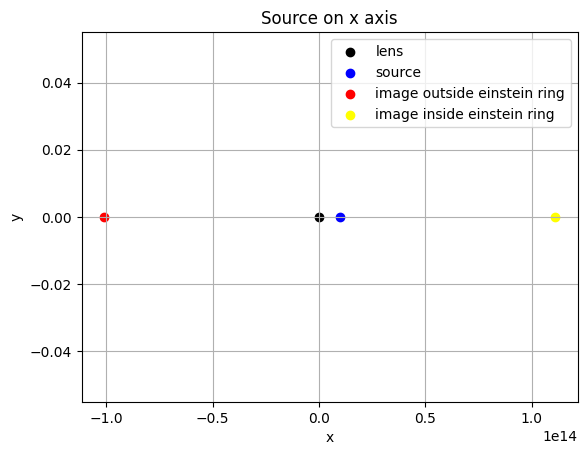

In [19]:
# xaxis-
x= 1e13
y = 0
title = 'Source on x axis'
images_plot(x, y )
plt.title(title)
plt.show()

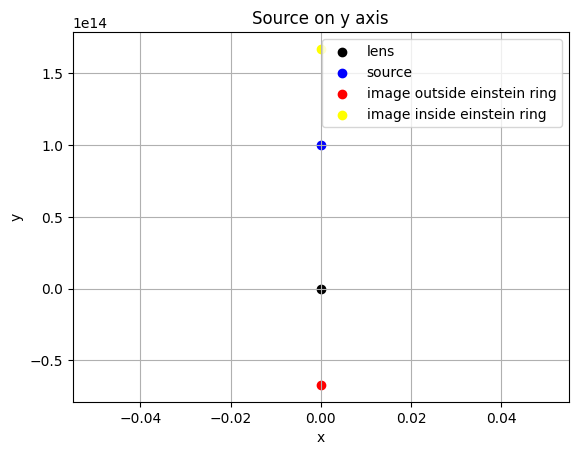

In [20]:
#y axis
x = 0
y = 1e14
t = 'Source on y axis'
images_plot(x, y)
plt.title(t)
plt.show()


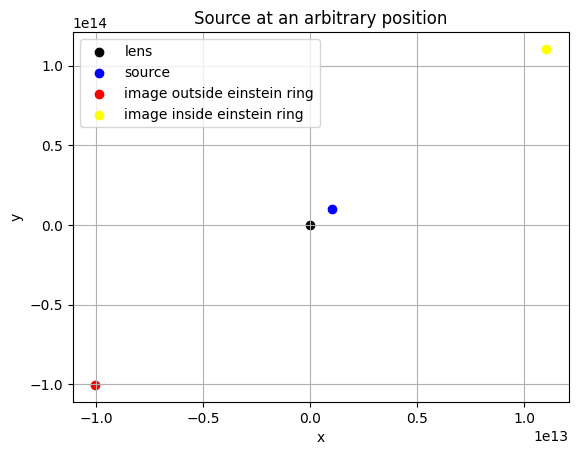

In [21]:
# arbitrary position
x = 1e12
y = 1e13
title = 'Source at an arbitrary position'
images_plot(x, y)
plt.title(title)
plt.show()

Observation - source, lens position on the plane, and the two images lies on the same plane. This must be true because the light ray refracted lies on the same plane as of images , lens and observer.

## Part (d): Extended Sources

In this part, you will extend your simulation from a single point source to an **extended source**, modelled as a collection of multiple points.

Assume the source is a small circular region centred at $(x_0, y_0)$ with radius $R$. This can be approximated by sampling many points within the circle.

### Task
Plot:
   - Original source points (blue, small markers)
   - Corresponding lensed image points (red/yellow)

### Suggested Parameters

- Number of points: 150–300

### Notes

- Use very small marker sizes ($s \leq 5$) for clarity
- You should observe distortion of the circular source near alignment
- You can plot both source points and image points on the same plane by considering angular variation only (i.e., plotting the points in terms of $\theta_x$ and $\theta_y$, where $\theta_x$, $\theta_y$ represent the angular separation from the source in the x and y directions).

---

## Explaination -
Creating a scatter of points so that it lie inside a circle of radius R and to make it look uniform i added the np.sqrt function in the random function for radial distance.

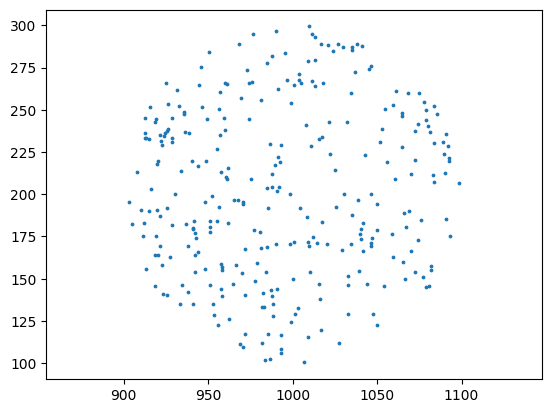

In [22]:
import numpy as np
import matplotlib.pyplot as plt
x0 = 1e3
y0 = 2e2
R = 1e2
N = 300
r_rand = R * np.sqrt(np.random.uniform(0, 1, N))  # to make the radial distribution look uniform
theta_rand = np.random.uniform(0, 2*np.pi, N)
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
plt.scatter(xo, yo, s = 3)
plt.axis('equal')
plt.show()


## Defining function for finding both the $\theta$'s for a given $\beta$

In [23]:
def pos_calc_plus(x, y):
    r = np.sqrt(x**2 + y**2)
    b = np.arctan(r/ds)
    tm = the_minus(b, theta_E)
    tp = the_plus(b, theta_E)
    do_m = ds*np.tan(tm)
    do_p = ds * np.tan(tp)
    ct = x/np.sqrt(x*x+y*y)
    st = y/np.sqrt(x*x+y*y)
    xm = do_m * ct
    ym = do_m * st
    xp = do_p *ct
    yp = do_p * st
    return xp, yp
def pos_calc_minus(x, y):
    r = np.sqrt(x**2 + y**2)
    b = np.arctan(r/ds)
    tm = the_minus(b, theta_E)
    tp = the_plus(b, theta_E)
    do_m = ds*np.tan(tm)
    do_p = ds * np.tan(tp)
    ct = x/np.sqrt(x*x+y*y)
    st = y/np.sqrt(x*x+y*y)
    xm = do_m * ct
    ym = do_m * st
    xp = do_p *ct
    yp = do_p * st
    return xm, ym

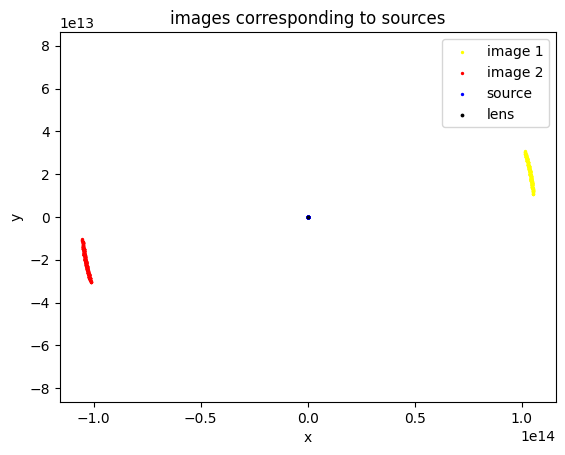

In [24]:
xi_p , yi_p = pos_calc_plus(xo, yo)
xi_m, yi_m = pos_calc_minus(xo, yo)
plt.scatter(xi_p, yi_p, color = 'yellow', label = 'image 1', s= 2)
plt.scatter(xi_m, yi_m, color = 'red', label = 'image 2', s= 2)
plt.scatter(xo, yo, color = 'blue', label = 'source', s= 2)
plt.scatter(0, 0, color = 'black', label = 'lens', s= 3)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('images corresponding to sources')
plt.axis('equal')
plt.show()


## observations -
For large xo and yo image1 and object are too close and lens and image2 are also too close and for small xo and yyo we observe the formation of einstein ring.

## Part (e): Formation of an Einstein Ring

In this part, you will study how an **Einstein ring** forms as the source becomes increasingly aligned with the lens.

### Task

1. Consider a point source located along the vertical axis:
   $$
   S = (0, y)
   $$

2. Choose a sequence of source positions approaching perfect source-lens alignment along vertical axis.

3. Create **five separate plots**, one for each value of $y$:
   - Plot the source (blue)
   - Plot both image positions (red/yellow)
   - Plot the lens at the origin (black)

### Notes
- Ensure consistent axis limits across all plots for comparison  


In [25]:
y_pos = np.array([1e8, 1e5, 5e3, 8e2, 2e2])
x_pos = np.array([0, 0, 0, 0, 0])
# considering a 2d celestial body
R = 5e2
N = 300
r_rand = R * np.sqrt(np.random.uniform(0, 1, N))  # to make the radial distribution look uniform
theta_rand = np.random.uniform(0, 2*np.pi, N)


Subplots weren't clear so i made individual plots.

## PLOT - 1 and PLOT 2
When source is very far from the lens, then we do not observe any ring formation. What we observe is only 2 dots. That's what we see in plot 1 and 2.

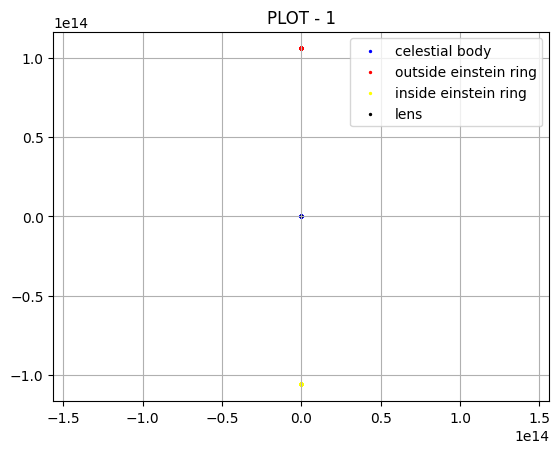

In [26]:
#plot 1 - star very far
x0 = 0
y0 = y_pos[0]
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xp, yp = pos_calc_plus(xo, yo)
xm , ym = pos_calc_minus(xo, yo)
plt.scatter(xo, yo, color = 'blue', label = 'celestial body', s= 2)
plt.scatter(xp, yp, color = 'red', label = 'outside einstein ring', s= 2)
plt.scatter(xm, ym, color = 'yellow', label = 'inside einstein ring', s= 2)
plt.scatter(0, 0, color = 'black', label = 'lens', s =2 )
plt.title('PLOT - 1')
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()



In this scenario, you may not be able to seee the lens and the souce because both are masked by the images

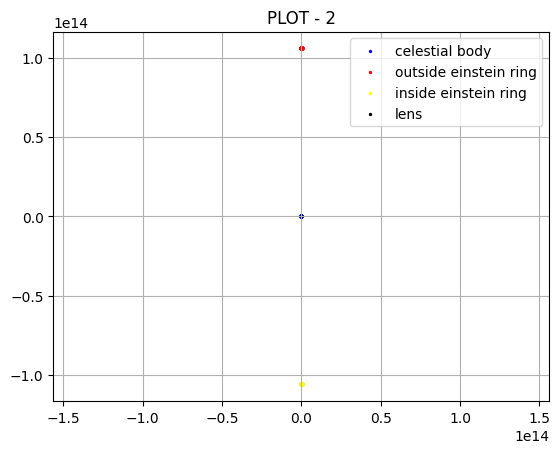

In [27]:
#plot 2- star comes nearer

x0 = 0
y0 = y_pos[1]
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xp, yp = pos_calc_plus(xo, yo)
xm , ym = pos_calc_minus(xo, yo)
plt.scatter(xo, yo, color = 'blue', label = 'celestial body', s= 2)
plt.scatter(xp, yp, color = 'red', label = 'outside einstein ring', s= 2)
plt.scatter(xm, ym, color = 'yellow', label = 'inside einstein ring', s= 2)
plt.scatter(0, 0, color = 'black', label = 'lens', s = 2)
plt.axis('equal')
plt.title('PLOT - 2')
plt.legend()
plt.grid()
plt.show()


## PLOT - 3
As the source tries to be align with observer and lens, we observe that the image slowly extends. Thus Einstein rings starts forming slowly.

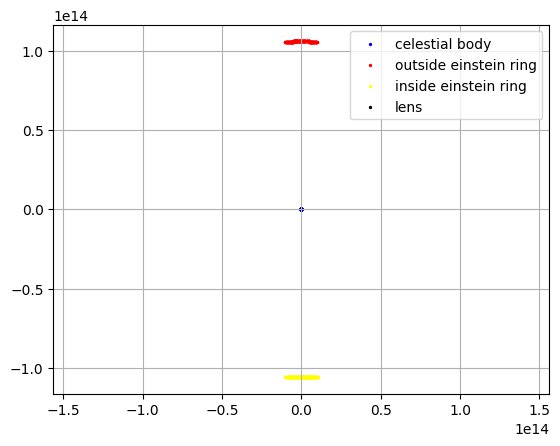

In [28]:
#plot 3
#plot 1 - star very far
x0 = 0
y0 = y_pos[2]
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xp, yp = pos_calc_plus(xo, yo)
xm , ym = pos_calc_minus(xo, yo)
plt.scatter(xo, yo, color = 'blue', label = 'celestial body', s= 2)
plt.scatter(xp, yp, color = 'red', label = 'outside einstein ring', s= 2)
plt.scatter(xm, ym, color = 'yellow', label = 'inside einstein ring', s= 2)
plt.scatter(0, 0, color = 'black', label = 'lens', s = 2)
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()




## PLOT - 4 AND 5
The curvature of circle becomes clearer as the source becomes more align with lens. We can observe this in plot 4 and 5.

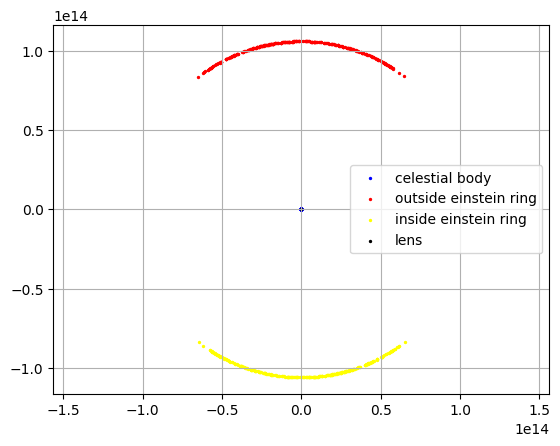

In [29]:
#plot 4 - star comes nearer
x0 = 0
y0 = y_pos[3]
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xp, yp = pos_calc_plus(xo, yo)
xm , ym = pos_calc_minus(xo, yo)
plt.scatter(xo, yo, color = 'blue', label = 'celestial body', s= 2)
plt.scatter(xp, yp, color = 'red', label = 'outside einstein ring', s= 2)
plt.scatter(xm, ym, color = 'yellow', label = 'inside einstein ring', s= 2)
plt.scatter(0, 0, color = 'black', label = 'lens', s = 2)
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()



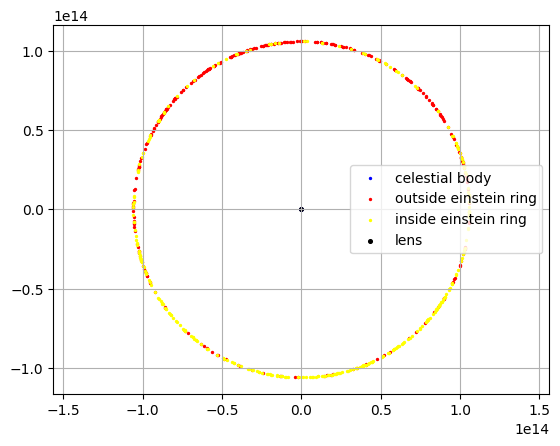

In [30]:
#plot 5 - star extremely near
x0 = 0
y0 = y_pos[4]
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xp, yp = pos_calc_plus(xo, yo)
xm , ym = pos_calc_minus(xo, yo)
plt.scatter(xo, yo, color = 'blue', label = 'celestial body', s= 2)
plt.scatter(xp, yp, color = 'red', label = 'outside einstein ring', s= 2)
plt.scatter(xm, ym, color = 'yellow', label = 'inside einstein ring', s= 2)
plt.scatter(0, 0, color = 'black', label = 'lens', s = 7)
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()


## Observations-
As the source comes towards origin we see that images forms some kind of ring. this is known as einstein ring

## Part (f): Original Image Reconstruction from Lensed Image

For this part, you are provided a set of points, that represents the lensed image of a celestial body. The coordinates of the lens are given to be (0, 0).
Use the provided [lensed_points.csv](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/lensed_points.csv)
### Task:

1. Derive the inverse transformation to find the set of coordinates corresponding to the original image.
2. Consider a celestial object represented by the set of coordinates in the .csv file. These represent the coordinates in the normalised angular space (i.e. in terms of $\theta_x/\theta_E$ and $\theta_y/\theta_E$).
3. Use the derived transformation to find the set of coordinates for the actual image. Plot it, using a suitable scale.

# Explaination
## Deriving inverse coordinates transformation
$$\beta = \theta - \frac{\theta_E^2}{\theta}$$ for small $\theta$
Hence we can use this relation to find the coordinates of the actual image


Extracting data of each column into 4 seperate arrays

# Please upload the 'lensed_points.csv' file

In [31]:
from google.colab import files
uploaded = files.upload()

Saving lensed_points.csv to lensed_points (1).csv


In [32]:
tx1_te = []
ty1_te = []
tx2_te = []
ty2_te = []

with open('lensed_points.csv', 'r') as f:
    lines = f.read().split('\n')

lines = lines[1:]
for data in lines:
    if data:
        data = data.split(',')
        tx1_te.append(float(data[0]))
        ty1_te.append(float(data[1]))
        tx2_te.append(float(data[2]))
        ty2_te.append(float(data[3]))

tx1_te = np.array(tx1_te)
ty1_te = np.array(ty1_te)
tx2_te = np.array(tx2_te)
ty2_te = np.array(ty2_te)

PLotting the extracted data into a seperate plot to check

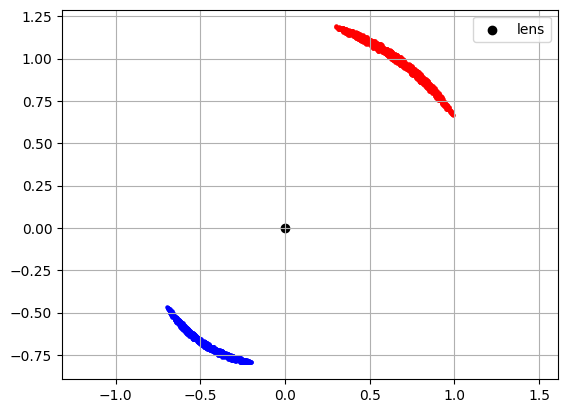

In [40]:
plt.scatter(tx1_te, ty1_te, color = 'red', s= 5)
plt.scatter(tx2_te, ty2_te, color = 'blue', s = 5)
plt.scatter(0, 0, color = 'black', label = 'lens')
plt.legend()
plt.grid()
plt.axis('equal')
t1_normed = np.sqrt(tx1_te** 2 + ty1_te**2)
t2_normed = np.sqrt(tx2_te**2 + ty2_te**2)

All magnuitudes of $\frac{\theta}{\theta_E}$ in t1_normed are > 1 and in t2_normed less than 1. So i can say that all
the first 2 column in the csv file corresponds to data outside einstein ring and other two inside einstein ring

In [34]:
def src_pos(tr_x, tr_y):
    tr = np.sqrt(tr_x**2 + tr_y**2)
    br = tr - 1/tr
    sf = br/tr
    br_x = sf * tr_x
    br_y = sf* tr_y
    return br_x, br_y
bx , by = src_pos(tx1_te, ty1_te)
bx1, by1 = src_pos(tx2_te, ty2_te)
b = bx**2 + by**2
b1 = bx1**2 + by1**2
c = 0
c1 =0
for e in b:
    if (np.abs(e)>4):
        c += 1
for e in b1:
    if (np.abs(e)>4):
        c1 += 1
print (c, c1)


0 0


Since the total number of points where $\beta / \theta_E$ is greater than 4 is 0 so we can assume the approximate formula of finding relation between $\beta$ and $\theta$

## PLOTTING THE POSITION OF ORIGINAL SOURCE

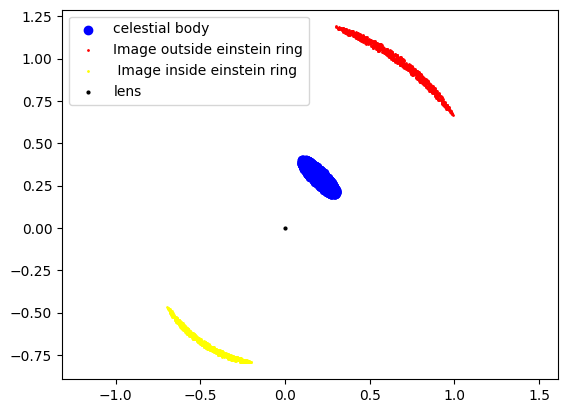

In [35]:
plt.scatter(bx, by, color = 'blue' , label = "celestial body")
plt.scatter(bx1, by1, color = 'blue' )
plt.scatter(tx1_te, ty1_te, color = 'red', s= 1, label = "Image outside einstein ring")
plt.scatter(tx2_te, ty2_te, color = 'yellow', s = 1, label = " Image inside einstein ring ")
plt.scatter(0, 0, color = 'black',s = 4, label = 'lens')
plt.axis('equal')
plt.legend()
plt.show()

The blue region shows the position of the celestial body.
We have $\theta_E$, $d_s$ ,so we can find the x and y coordinates.
We can see that the celestial body is in blue color . Now calculating it's coordinates by substituting the values of $d_s$ and $\theta_E$ from previous workout.

In [36]:
tx_c = np.mean(bx+bx1)
ty_c = np.mean(by+by1)

print (f"the coordinates of the celestial body's centre is ({tx_c:.2f}, {ty_c:.2f}) and it spans over ({np.min(bx+bx1):.2f}, {np.max(bx+bx1):.2f}) along x axis and ({np.min(by+by1):.2f}, {np.max(by+by1):.2f}) along y axis." )

the coordinates of the celestial body's centre is (0.40, 0.60) and it spans over (0.20, 0.60) along x axis and (0.40, 0.80) along y axis.


 So the coordinates of centre of celestial body is approximately (0.4, 0.4) and extends from (0.2, 0.6) along x axis and from (0.4,0.8) along y axis in units of $\theta_x / \theta_E$ and $\theta_y / \theta_E$

Now using the values of $\theta_E$ and $d_s$

In [37]:
x_c = theta_E * tx_c * ds
y_c = theta_E * ty_c * ds
print (f"coordinates of celestial body is ({x_c:.2f}, {y_c:.2f}) in metres")

coordinates of celestial body is (42358237542836.32, 63843852454487.30) in metres


## Part (g): Bonus Question
You are provided with an actual 24-bit bitmap image ([hubble-lrg3757.bmp](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/hubble-lrg3757.bmp)) of a lensed galaxy, a nearly perfect Einstein Ring (Source: [NASA - LRG 3-757](https://science.nasa.gov/image-detail/einstein-ring-lrg-3-757/)). Use the transformation derived earlier and find the actual, de-lensed image of the galaxy (what the galaxy would look like if the original foreground cluster were not present).
![LRG 3-757](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/refs/heads/main/Computational_Astronomy/hubble-lrg3757.bmp)
###Task:
1. Import the image as a NumPy array. (Convert to Grayscale if necessary)
2. Write a script to map the pixels of the lensed image back to their source positions, You may have to crop the image suitably, use thresholding to identify bright regions of the image. You may refer to the OpenCV documentation here:- https://docs.opencv.org/4.x/index.html
3. Use $d_L$ = 6.3 $\times$ $10^9$ light years, $d_S$ = 10.9 $\times$ $10^9$ light years (refer to the diagram for the notation).

## Explaination
Cropping the image and extracting details about it.

# Please upload the image 'hubble-lrg3757.bmp'


In [41]:
from google.colab import files
uploaded = files.upload()

Saving hubble-lrg3757.bmp to hubble-lrg3757.bmp


Isolating einstein ring

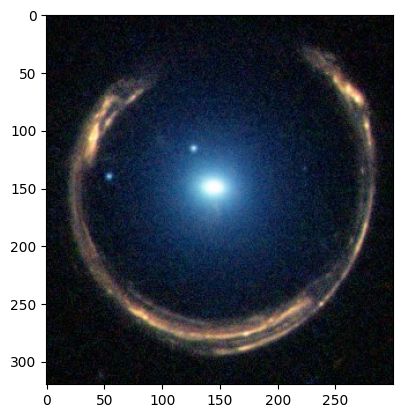

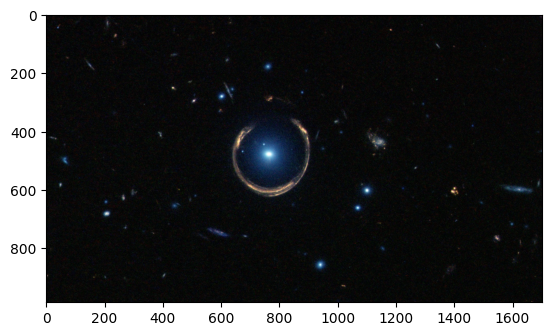

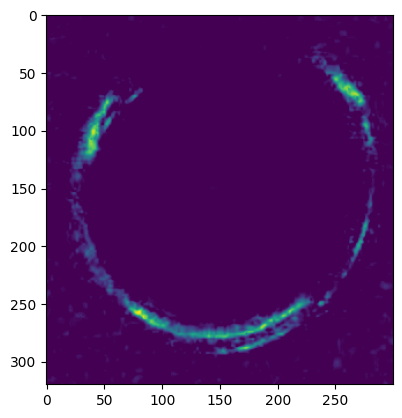

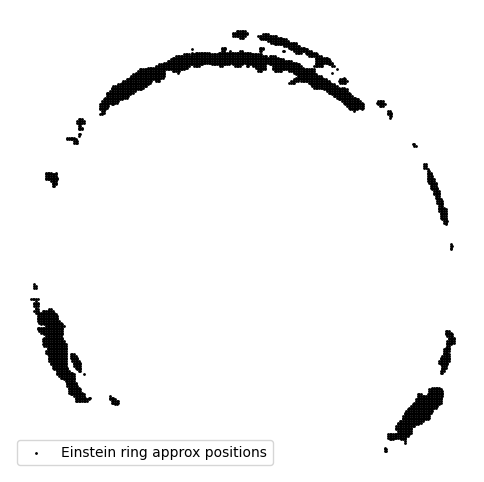

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img_bgr = cv2.imread('hubble-lrg3757.bmp')
crop = img_bgr[330:650, 620:920].copy()
ring = []
B, G, R = cv2.split(crop)
plt.imshow(crop)
plt.show()
iso_blue = cv2.subtract(B, R)
plt.imshow(img_bgr)
plt.show()
plt.imshow(iso_blu)
plt.show()
for y, row in enumerate(iso_blu):
    for x, blu_val in enumerate(row):
        if blu_val > 30:
            ring.append([x, y])
x_coords = [p[0] for p in ring]
y_coords = [p[1] for p in ring]

plt.figure(figsize=(6, 6))

plt.scatter(x_coords, y_coords, color='black', s=1, label='Isolated einstein ring')
plt.legend()
plt.axis('off')
plt.show()

from the plots we can estimate that the position of lens must be about 150, 150 in cropped picture. Lens is the brightest spot in the picture.

In [45]:

xl, yl = 150, 150
centred_ring = np.array(ring) - np.array([xl, yl])

Finding the einstien radius in pixels.
Remember the equation - $\beta = \theta - \theta_E^2 / \theta$ so the product of roots is $\theta_E^2$. Thus to get a better estimate of $\theta_E$ its better to take the geometric mean of all possible magnitudes of normed $\theta$

In [46]:
normed_theta = []
for data in centred_ring:
    normed_theta.append(np.linalg.norm(data))
from scipy.stats import gmean
normed_theta = np.array(normed_theta)
theta_e = gmean(normed_theta)
print(np.min(normed_theta))
print(f"Geometric Mean (theta_E): {theta_e:.2f} pixels")

106.88779163215975
Geometric Mean (theta_E): 128.05 pixels


In [47]:
obj_pos_centred = []
for data in centred_ring:
    xi= data[0]/ theta_e
    yi = data[1]/ theta_e
    xo, yo = src_pos(xi, yi)
    obj_pos_centred.append([xo, yo])
obj_pos = np.array(obj_pos_centred)*theta_e + np.array([xl, yl])
xo = []
yo = []
for data in obj_pos:
    xo.append(data[0])
    yo.append(data[1])
xo = np.array(xo)
yo = np.array(yo)


## Getting a sample plot of how galaxy may be oriented in the space behind the lens and its dimensions with respect to the rings

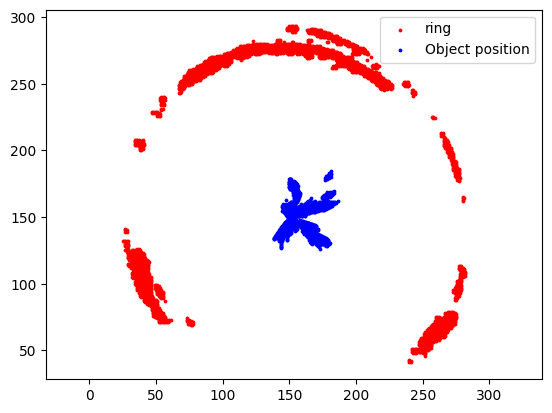

In [48]:
plt.scatter(x_coords, y_coords, color = 'red' , label = "ring", s = 3)
plt.scatter(xo, yo, color = 'blue' , label = "Object position", s = 3)
plt.legend()
plt.axis('equal')
plt.show()

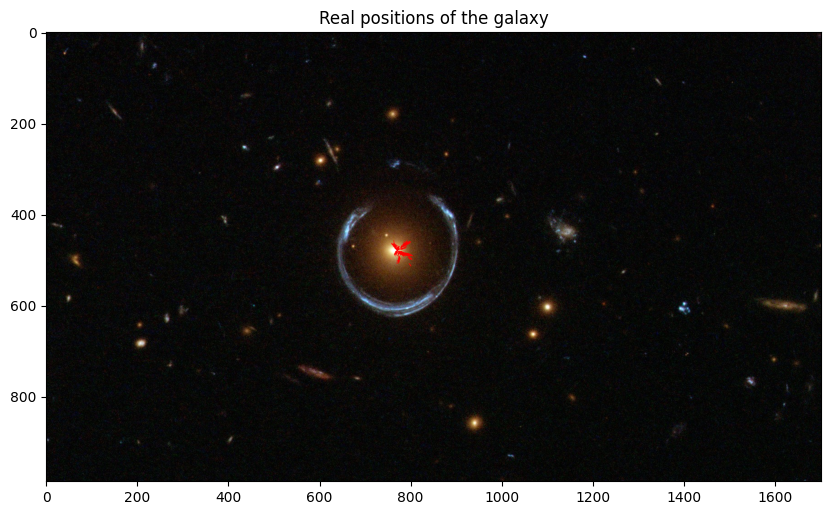

In [49]:

img_overlay = img_bgr.copy()
x_mapped = np.round(xo + 620).astype(int)
y_mapped = np.round(yo + 330).astype(int)
for i in range(len(x_mapped)):
    img_overlay[y_mapped[i], x_mapped[i]] = [0, 0, 255]
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
plt.title("Real positions of the galaxy")
plt.show()

The red markers in the above image shows the approximate position of galaxy in the picture show.

Now finding the distance of galaxy from the line of sight along lens and observer. The mass of lens = 10 * mass of milky way = $1.5 * 10^{12} * 2*10^{30} * 10 $ = $3 * 10^{52} Kg$

In [54]:
M = 3e52
G = 6.67e-11
c = 3e8
dl = 6.3e9
ds= 10.9e9
dls = ds - dl
dl *= 9.46e15
ds *= 9.46e15
dls *= 9.46e15
dls

4.3516e+25

Finding the mean position of galaxy

In [55]:
x_galaxy = np.mean(x_mapped)
y_galaxy = np.mean(y_mapped)
print(x_galaxy, y_galaxy)

776.5869908430692 479.6274076413009


In [57]:
theta_e = einstein(dl, ds, dls)
theta_e

np.float64(0.7935642765806279)

This theta_e is equivalent to 128.05 pixels we previously found. Finding pixel distance between mean position of galaxy to the lens.

In [59]:
lens_pos = np.array([xl + 620, yl + 330])
galaxy_pos = np.array([x_galaxy, y_galaxy]) - lens_pos
theta_x, theta_y = galaxy_pos * theta_e / 128.05

In [61]:
x_coord_galaxy = theta_x * ds
y_coord_galaxy = theta_y * ds
dist_from_lens = np.sqrt(x_coord_galaxy**2 + y_coord_galaxy**2)

In [63]:
print ("the distance of the lens centre from galaxy behind along it's plane = " , dist_from_lens, 'metres')

the distance of the lens centre from galaxy behind along it's plane =  4.2160028185795203e+24 metres
